# IE0005 Mini Project — Toxic Comment Multi-Label Classification
### Team: DSAI EL17 | Sriman, Aravinth, Lavantika, Louise

**Objective:** Build a machine learning pipeline to automatically detect and classify 
toxic comments from Wikipedia across 6 toxicity categories: toxic, severe_toxic, 
obscene, threat, insult, and identity_hate.

**Dataset:** Kaggle Toxic Comment Classification Challenge  
**Approach:** TF-IDF + Engineered Features → Logistic Regression (multi-label, one-vs-rest)

# 0. Setup & Libraries

We import the core libraries needed throughout the pipeline:
- `pandas` / `numpy` for data manipulation
- `matplotlib` / `seaborn` for visualisation
- `re` for text cleaning with regular expressions

In [7]:
#Import libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt 
sb.set() 
import re

# 1. Data Loading

The dataset comes from the Kaggle Toxic Comment Classification Challenge.
It consists of 3 files:
- `train.csv` — 159,571 labelled Wikipedia comments (used to train models)
- `test.csv` — 153,164 unlabelled comments (used for final predictions)
- `test_labels.csv` — ground truth labels for the test set (rows with -1 are excluded from evaluation)

Each comment can carry **multiple labels simultaneously** (multi-label problem),
e.g. a comment can be both `toxic` AND `obscene` AND `insult` at the same time.

In [8]:
#train set(training ml models)
train_data = pd.read_csv('train.csv')
train_data.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [9]:
#test set (to make predictions)
test_data = pd.read_csv("test.csv")
test_data.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [10]:
#test_labels set (evaluating performance)
testlabels_data = pd.read_csv("test_labels.csv")
testlabels_data.head()

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,-1,-1,-1,-1,-1,-1
1,0000247867823ef7,-1,-1,-1,-1,-1,-1
2,00013b17ad220c46,-1,-1,-1,-1,-1,-1
3,00017563c3f7919a,-1,-1,-1,-1,-1,-1
4,00017695ad8997eb,-1,-1,-1,-1,-1,-1


In [11]:
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("Test Labels shape:", testlabels_data.shape)

Train shape: (159571, 8)
Test shape: (153164, 2)
Test Labels shape: (153164, 7)


In [12]:
print("\nTrain columns:")
print(train_data.columns)

print("\nTest columns:")
print(test_data.columns)


Train columns:
Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

Test columns:
Index(['id', 'comment_text'], dtype='object')


# 2. Exploratory Data Analysis (EDA)

Before building any model, we explore the dataset to understand its structure,
distributions, and potential challenges.

Key questions we answer here:
1. How imbalanced is the data between toxic and non-toxic comments?
2. How are the 6 toxicity labels distributed?
3. Are the labels correlated with each other? (justifies multi-label approach)

### 2.1 Summary Statistics
Basic statistical overview of the train and test sets.

In [13]:
# train data stats
train_data.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
# test data stats
test_data.describe()

,id,comment_text
count,153164,153164
unique,153164,153164
top,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
freq,1,1


In [15]:
# train dataset info
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [16]:
# test dataset info
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            153164 non-null  object
 1   comment_text  153164 non-null  object
dtypes: object(2)
memory usage: 2.3+ MB


### 2.2 Toxic vs Non-Toxic Class Distribution

We define a comment as toxic if ANY of the 6 labels = 1, and non-toxic if ALL labels = 0.
This bar chart reveals that the dataset is **highly imbalanced**: ~90% of comments are 
non-toxic. This imbalance must be addressed during modelling to avoid the model 
simply predicting "non-toxic" for everything.

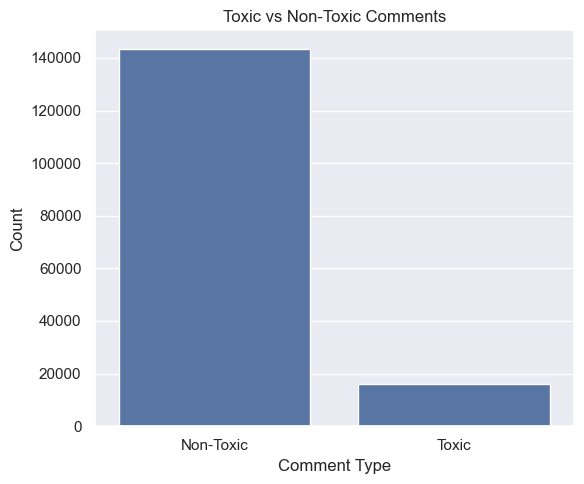

In [17]:
# Bar chart: toxic vs non-toxic comments Ctrain set)
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

train_data["is_toxic_any"] = (train_data[label_cols].sum(axis=1) > 0).astype(int)

toxicity_summary = train_data["is_toxic_any"].value_counts().sort_index()
toxicity_summary.index = ["Non-Toxic", "Toxic"]

plt.figure(figsize=(6, 5))
sb.barplot(x=toxicity_summary.index, y=toxicity_summary.values)
plt.title("Toxic vs Non-Toxic Comments")
plt.xlabel("Comment Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#The dataset is imbalanced, with significantly more non-toxic comments.
#If ANY label = 1 → mark as toxic (1)
#If ALL labels = 0 → mark as non-toxic (0)

### 2.3 Distribution of Toxicity Labels

Among toxic comments, the 6 labels are not equally represented:
- `toxic`, `obscene`, `insult` are relatively common
- `threat` and `identity_hate` are **severely underrepresented** (minority labels)

This within-class imbalance means the model will naturally struggle more with rare labels,
which we address in the Optimisation section.

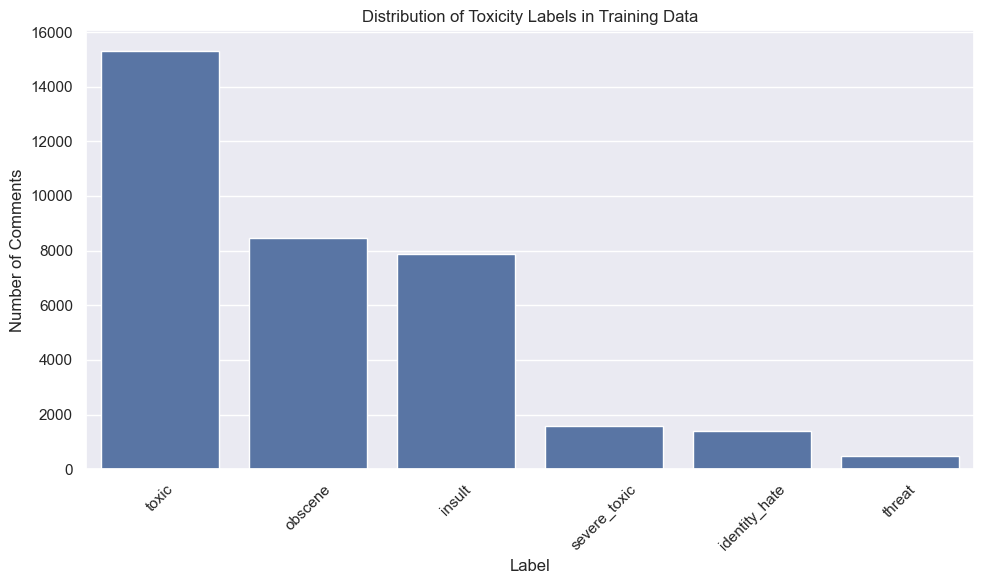

In [18]:
# Bar chart: count of each toxicity label Ctrain set)

label_counts = train_data[label_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sb.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Distribution of Toxicity Labels in Training Data")
plt.xlabel("Label")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Toxic comments further distributed into different labels
#Labels like ‘threat’ and ‘identity_hate’ are underrepresented, which may affect model performance.

### 2.4 Correlation Heatmap of Toxicity Labels

This heatmap shows how labels co-occur in the same comment.
- Strong correlations (e.g. toxic↔obscene: 0.68, obscene↔insult: 0.74) confirm that 
  toxicity categories frequently overlap — justifying a **multi-label** rather than 
  single-label classification approach.
- Weak correlations for `threat` suggest it tends to appear independently.

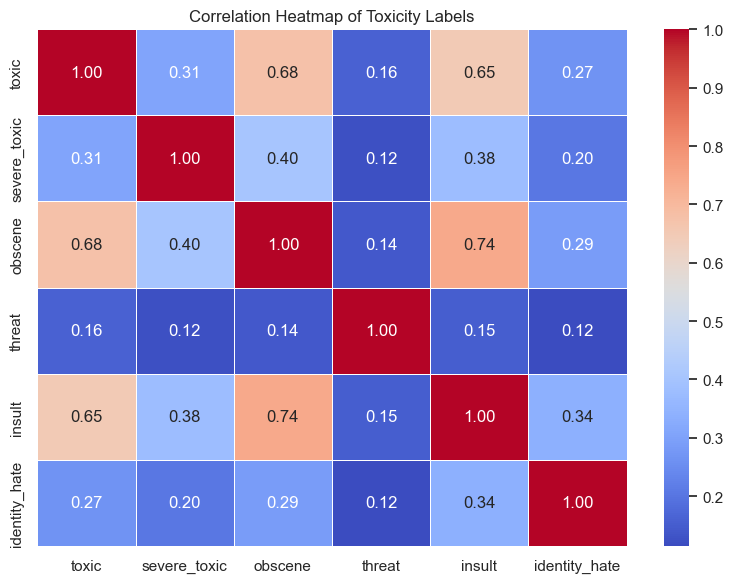

In [19]:
# Heatmap: correlation between toxicity labels Ctrain set)
#Checks how labels relate to each other

plt.figure(figsize=(8, 6))
corr_matrix = train_data[label_cols].corr()

sb.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Toxicity Labels")
plt.tight_layout()
plt.show()
#“Certain labels such as ‘toxic’ and ‘insult’ are positively correlated, indicating overlapping behaviour.”

# 3. Data Cleaning

Raw Wikipedia comments contain noise that would confuse the model: HTML tags, 
special characters, contractions, and mixed capitalisation. We standardise the 
text before feature extraction.

Steps applied:
1. **Fill missing values** with empty strings (technical safety before processing)
2. **Lowercase** all text (so "HATE" and "hate" are treated as the same word)
3. **Remove HTML tags** (e.g. `<br/>`, `<b>`) left over from Wikipedia markup
4. **Expand contractions** (e.g. "can't" → "can not", "i'm" → "i am") so negations 
   are preserved as full tokens
5. **Remove unwanted characters** — keep only letters and spaces; strip numbers and 
   punctuation that add noise
6. **Remove empty comments** (train set only) — comments that become empty after 
   cleaning carry no signal and would mislead training

### 3.1 Fill Missing Values

In [20]:
# fill null values/missing comments before cleaning (technical safety)
train_data["comment_text"] = train_data["comment_text"].fillna("")
test_data["comment_text"] = test_data["comment_text"].fillna("")

### 3.2 Text Cleaning Function

The `clean_text()` function applies all cleaning steps in sequence.
Note: contractions are expanded *before* removing punctuation so that 
apostrophes are handled correctly.

In [21]:
#create a text cleaning function to clean raw text

def clean_text(text):
    text = str(text)
    text = text.lower()

    # remove html tags
    text = re.sub(r'<.*?>', ' ', text)

    # expand contractions
    text = re.sub(r"what's", "what is ", text)
    text = re.sub(r"\'s", " ", text)
    text = re.sub(r"\'ve", " have ", text)
    text = re.sub(r"can't", "can not ", text)
    text = re.sub(r"n't", " not ", text)
    text = re.sub(r"i'm", "i am ", text)
    text = re.sub(r"\'re", " are ", text)
    text = re.sub(r"\'d", " would ", text)
    text = re.sub(r"\'ll", " will ", text)
    text = re.sub(r"\'scuse", " excuse ", text)

    # remove number-containing tokens
    text = re.sub(r'\b\w*\d+\w*\b', ' ', text)

    # keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

### 3.3 Apply Cleaning to Train and Test Sets

In [22]:
#apply text cleaning on train data
train_data["clean_comment"] = train_data["comment_text"].apply(clean_text)
test_data["clean_comment"] = test_data["comment_text"].apply(clean_text)

In [23]:
#cleaned textual train data
train_data[["comment_text", "clean_comment"]].head(10)

,comment_text,clean_comment
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i am s...
2,"Hey man, I'm really not trying to edit war. It...",hey man i am really not trying to edit war it ...
3,"""\nMore\nI can't make any real suggestions on ...",more i can not make any real suggestions on im...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...
5,"""\n\nCongratulations from me as well, use the ...",congratulations from me as well use the tools ...
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,cocksucker before you piss around on my work
7,Your vandalism to the Matt Shirvington article...,your vandalism to the matt shirvington article...
8,Sorry if the word 'nonsense' was offensive to ...,sorry if the word nonsense was offensive to yo...
9,alignment on this subject and which are contra...,alignment on this subject and which are contra...


In [24]:
#cleaned textual test data
test_data[["comment_text", "clean_comment"]].head(10)

,comment_text,clean_comment
0,Yo bitch Ja Rule is more succesful then you'll...,yo bitch ja rule is more succesful then you wi...
1,== From RfC == \n\n The title is fine as it is...,from rfc the title is fine as it is imo
2,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",sources zawe ashton on lapland
3,":If you have a look back at the source, the in...",if you have a look back at the source the info...
4,I don't anonymously edit articles at all.,i do not anonymously edit articles at all
5,Thank you for understanding. I think very high...,thank you for understanding i think very highl...
6,Please do not add nonsense to Wikipedia. Such ...,please do not add nonsense to wikipedia such e...
7,:Dear god this site is horrible.,dear god this site is horrible
8,""" \n Only a fool can believe in such numbers. ...",only a fool can believe in such numbers the co...
9,== Double Redirects == \n\n When fixing double...,double redirects when fixing double redirects ...


### 3.4 Remove Empty Comments (Train Only)

Empty post-cleaning comments in the **train set** are dropped — they provide no 
useful signal. For the **test set**, we keep all rows (replacing empty with a 
placeholder) to ensure our final predictions cover every required ID.

In [25]:
# TRAIN → remove empty rows (useless rows)
train_data = train_data[train_data["clean_comment"].str.strip() != ""].copy()
train_data.reset_index(drop=True, inplace=True)

# TEST → keep all rows
test_data["clean_comment"] = test_data["clean_comment"].fillna("").str.strip()
test_data["clean_comment"] = test_data["clean_comment"].replace("", "emptycomment")

#Final check for any null/missing values
print("Empty comments after cleaning (train data):",
      (train_data["clean_comment"] == "").sum())
print("Empty comments after cleaning (test data):",
      (test_data["clean_comment"] == "").sum())

Empty comments after cleaning (train data): 0
Empty comments after cleaning (test data): 0


### 3.5 Save Cleaned Data
Exporting cleaned datasets to CSV so cleaning does not need to be re-run.

In [26]:
#saving cleaned train textual data in new csv file
train_data.to_csv("train_cleaned.csv", index=False)
test_data.to_csv("test_cleaned.csv", index=False)

# 4. Data Reprocessing & Feature Engineering

Cleaned text needs to be converted into numerical form before it can be fed into 
a machine learning model. We do this in two steps:

1. **Feature Engineering** — extract hand-crafted numerical signals from the raw text
2. **TF-IDF Vectorisation** — convert cleaned comment text into a sparse matrix of 
   word importance scores
3. **Scaling + Combining** — standardise the engineered features and combine them 
   with TF-IDF into a single feature matrix

### 4.1 Feature Engineering

Beyond the text itself, certain writing patterns correlate with toxicity.
We extract 5 additional numeric features from each comment:

| Feature | Source | Rationale |
|---|---|---|
| `word_count` | cleaned text | Longer comments may carry more toxicity signals |
| `char_count` | cleaned text | Captures comment length independently |
| `exclamation_count` | raw text | Aggressive tone indicator |
| `question_count` | raw text | Rhetorical hostility indicator |
| `uppercase_ratio` | raw text | SHOUTING is a toxicity signal |

Raw text is used for punctuation/uppercase features since cleaning removes these.

In [27]:
#Feature Engineering (train set)

train_data["char_count"] = train_data["clean_comment"].apply(len)   # length features
train_data["word_count"] = train_data["clean_comment"].apply(lambda x: len(x.split()))
train_data["exclamation_count"] = train_data["comment_text"].str.count("!")    # punctuation features
train_data["question_count"] = train_data["comment_text"].str.count(r"\?")
train_data["uppercase_ratio"] = train_data["comment_text"].apply(             # uppercase ratio
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
)
#Feature enginering (test set)
test_data["char_count"] = test_data["clean_comment"].apply(len)
test_data["word_count"] = test_data["clean_comment"].apply(lambda x: len(x.split()))
test_data["exclamation_count"] = test_data["comment_text"].str.count("!")
test_data["question_count"] = test_data["comment_text"].str.count(r"\?")
test_data["uppercase_ratio"] = test_data["comment_text"].apply(
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))

In [28]:
# Create test_eval AFTER cleaning and feature engineering are complete
# so test_eval inherits clean_comment and all engineered feature columns

label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

testlabels_clean = testlabels_data[
    (testlabels_data[label_cols] != -1).all(axis=1)
].reset_index(drop=True)

test_eval = test_data.merge(testlabels_clean, on="id")
print("Labelled test rows available for evaluation:", len(test_eval))
print("Columns in test_eval:", test_eval.columns.tolist())

Labelled test rows available for evaluation: 63978
Columns in test_eval: ['id', 'comment_text', 'clean_comment', 'char_count', 'word_count', 'exclamation_count', 'question_count', 'uppercase_ratio', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


### 4.2 Build Evaluation Test Set

We merge test comments with their labels (excluding rows marked -1, which were 
not evaluated in the original competition) to create `test_eval` — the set we 
use for final performance measurement.

In [29]:
#Separation of text and labels for train set to perform tf-idf
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

X = train_data["clean_comment"]   #tf-idf will be only done on comments, not on labels. 
y = train_data[label_cols]
X_test = test_data["clean_comment"]

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Check shapes
print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(127648,) (31912,)
(127648, 6) (31912, 6)


### 4.3 TF-IDF Vectorisation

**TF-IDF (Term Frequency–Inverse Document Frequency)** converts cleaned text into 
numerical feature vectors that capture word importance.

- **TF** (Term Frequency): how often a word appears in this comment  
- **IDF** (Inverse Document Frequency): penalises words that appear in almost every 
  comment (e.g. "the", "and") — common words carry less discriminative power

Key settings:
- `max_features=30000` — keep only the 30,000 most informative tokens
- `ngram_range=(1,2)` — include both single words AND two-word phrases 
  (bigrams like "hate you" capture context better than "hate" alone)
- Custom stopwords — we **keep** "no", "not", "nor", "never" because negation is 
  critical for correct toxicity interpretation ("I don't hate you" ≠ "I hate you")
- `sublinear_tf=True` — dampens very high raw term frequencies to reduce 
  the outsized influence of repeated words

In [30]:
#Performing TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
custom_stopwords = set(ENGLISH_STOP_WORDS) - {"no", "not", "nor", "never"}

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    stop_words=list(custom_stopwords),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    token_pattern=r'\b[a-zA-Z]{2,}\b'
)

X_train_tfidf = tfidf.fit_transform(X_train) #fits the model and transforms  data
X_val_tfidf = tfidf.transform(X_val) #only transforms into tf-idf values
X_test_tfidf = tfidf.transform(X_test) #only transforms into tf-idf values

### 4.4 Standard Scaling & Feature Combination

`StandardScaler` normalises the 5 engineered features to zero mean and unit variance,
ensuring they contribute proportionally alongside TF-IDF values (which are already 
small floats between 0 and 1).

The scaled engineered features are then **horizontally stacked** with the TF-IDF 
matrix using `scipy.sparse.hstack`, giving us the final feature matrix used for 
all model training.

In [31]:
# combine features and tf-idf values into 1 single array (feature engineering)
train_extra = train_data.loc[X_train.index, [
    "char_count", "word_count",
    "exclamation_count", "question_count",
    "uppercase_ratio"
]].values

val_extra = train_data.loc[X_val.index, [
    "char_count", "word_count",
    "exclamation_count", "question_count",
    "uppercase_ratio"
]].values

test_extra = test_data[[                          # fixed: reads from test_data, not train_data
    "char_count", "word_count",
    "exclamation_count", "question_count",
    "uppercase_ratio"
]].values

from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix, hstack

scaler = StandardScaler()

train_extra = scaler.fit_transform(train_extra)
val_extra   = scaler.transform(val_extra)
test_extra  = scaler.transform(test_extra)
#Combines: text features (TF-IDF) and numeric features (length, caps, etc.)
X_train_final = hstack([X_train_tfidf, csr_matrix(train_extra)])
X_val_final   = hstack([X_val_tfidf,   csr_matrix(val_extra)])
X_test_final  = hstack([X_test_tfidf,  csr_matrix(test_extra)])

print("X_train_final shape:", X_train_final.shape)
print("X_val_final shape:",   X_val_final.shape)
print("X_test_final shape:",  X_test_final.shape)

X_train_final shape: (127648, 30005)
X_val_final shape: (31912, 30005)
X_test_final shape: (153164, 30005)


In [32]:
#viewing features with highest tf-idf values
row = 0  
feature_names = tfidf.get_feature_names_out()
row_values = X_train_tfidf[row].toarray().flatten()

df = pd.DataFrame({
    'feature': feature_names,
    'tfidf': row_values
})

# show only non-zero values
df = df[df['tfidf'] > 0]

# sort by importance
df = df.sort_values(by='tfidf', ascending=False)
print(df.head(10))

                  feature     tfidf
4747            come mind  0.345767
16136  mutually exclusive  0.339791
16135            mutually  0.314315
12043         incorporate  0.291248
8591            exclusive  0.281403
28640             wanting  0.267715
27295              turkey  0.262755
5678              counter  0.249005
12083               india  0.225035
5215          considering  0.224592


#### Summary
1. Clean text and remove empty comments
2. Feature engineering
3. Train/validation split for TF-IDF
4. TF-IDF with stopwords removal
5. Combine features and scale 

# 5. Machine Learning Models

We build and compare two classifiers:

| Model | Features | Purpose |
|---|---|---|
| **Naive Bayes** | TF-IDF only | Baseline — fast, simple reference point |
| **Logistic Regression** | TF-IDF + engineered features | Main model — more expressive |

Both use a **One-vs-Rest (OvR)** strategy: a separate binary classifier is trained 
for each of the 6 toxicity labels independently. This is the standard approach for 
multi-label classification.

#### Variables to be used for Logistic Regression
X_train_final, y_train, X_val_final, y_val will be used to train the Logistic Regression model.

### 5.1 Baseline: Naive Bayes

Naive Bayes applies Bayes' Theorem under the **conditional independence assumption** — 
it treats each word as an independent signal, ignoring word order and context.

**Why it's the baseline:**
- Fast to train even on large sparse TF-IDF matrices
- Provides a strong reference point to measure how much Logistic Regression improves things

**Key constraint:** `MultinomialNB` requires **non-negative inputs**, so we cannot 
include the StandardScaler-transformed engineered features (which produce negative values). 
Naive Bayes is trained on TF-IDF only.

X_test_final/test_data will be used for making final predictions and test_labels is for evaluating performance

In [33]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score

# Naive Bayes is trained on TF-IDF only (no engineered features)
# because MultinomialNB cannot handle negative values produced by StandardScaler

nb_model = OneVsRestClassifier(MultinomialNB(alpha=0.1))
nb_model.fit(X_train_tfidf, y_train)

# Predictions on validation set
nb_val_preds = nb_model.predict(X_val_tfidf)

print("=== Naive Bayes (Baseline) — Validation Results ===\n")
print(classification_report(y_val, nb_val_preds, target_names=label_cols, zero_division=0))

# Per-label ROC-AUC
nb_val_probs = nb_model.predict_proba(X_val_tfidf)
for i, label in enumerate(label_cols):
    auc = roc_auc_score(y_val[label], nb_val_probs[:, i])
    print(f"ROC-AUC [{label}]: {auc:.4f}")

=== Naive Bayes (Baseline) — Validation Results ===

               precision    recall  f1-score   support

        toxic       0.87      0.58      0.70      3092
 severe_toxic       0.44      0.39      0.42       321
      obscene       0.85      0.61      0.71      1756
       threat       0.47      0.07      0.12       106
       insult       0.76      0.53      0.63      1633
identity_hate       0.42      0.22      0.29       293

    micro avg       0.80      0.55      0.65      7201
    macro avg       0.64      0.40      0.48      7201
 weighted avg       0.80      0.55      0.65      7201
  samples avg       0.05      0.05      0.05      7201

ROC-AUC [toxic]: 0.9506
ROC-AUC [severe_toxic]: 0.9746
ROC-AUC [obscene]: 0.9594
ROC-AUC [threat]: 0.9497
ROC-AUC [insult]: 0.9549
ROC-AUC [identity_hate]: 0.9509


### 5.2 Main Model: Logistic Regression

Logistic Regression applies the sigmoid function to a weighted sum of all features,
outputting a probability between 0 and 1 for each label. A prediction of 1 is made 
when this probability exceeds a threshold.

Key configuration choices:
- `solver='saga'` — efficient for large, sparse, high-dimensional datasets
- `class_weight='balanced'` — automatically upweights rare labels (threat, identity_hate) 
  during training so the model doesn't ignore them entirely
- `C=1.0` — regularisation strength (we tune this later in Optimisation)
- `max_iter=2000` — saga needs more iterations to converge on this dataset size

In [ ]:
from sklearn.linear_model import LogisticRegression

# class_weight='balanced' automatically adjusts weights inversely
# proportional to class frequency — this handles the severe imbalance
# (e.g. only 0.3% of comments are threats)

lr_model = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,                    # regularisation strength (lower = more regularisation)
        solver='saga',            # best solver for large sparse datasets
        class_weight='balanced',  # handles class imbalance
        max_iter=2000,
        random_state=42
    )
)

lr_model.fit(X_train_final, y_train)

# Predictions on validation set
lr_val_preds = lr_model.predict(X_val_final)

print("=== Logistic Regression (Main Model) — Validation Results ===\n")
print(classification_report(y_val, lr_val_preds, target_names=label_cols, zero_division=0))

# Per-label ROC-AUC
lr_val_probs = lr_model.predict_proba(X_val_final)
for i, label in enumerate(label_cols):
    auc = roc_auc_score(y_val[label], lr_val_probs[:, i])
    print(f"ROC-AUC [{label}]: {auc:.4f}")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### 5.3 Model Interpretability — Learned Feature Weights

By inspecting the coefficients (weights) learned by Logistic Regression for the `toxic` 
label, we can understand **what the model actually learned** — and identify its blind spots.

This analysis reveals 3 key findings (detailed in comments below the output):
1. Profanity completely dominates the toxic signal
2. Negation bigrams are partially captured but too weak to override profanity
3. Identity terms like "gay" received high toxic weights due to training data co-occurrence — 
   an early indicator of model bias

In [ ]:
# Extract learned weights from Logistic Regression for interpretability

tfidf_feature_names = list(tfidf.get_feature_names_out())
extra_feature_names = ["char_count", "word_count", "exclamation_count", 
                       "question_count", "uppercase_ratio"]
all_feature_names = tfidf_feature_names + extra_feature_names

# Weights for the toxic classifier (index 0)
toxic_weights = lr_model.estimators_[0].coef_[0]

weights_df = pd.DataFrame({
    "feature": all_feature_names,
    "weight": toxic_weights
})

# Top 20 words/bigrams pushing TOWARDS toxic
print("=== Top 20 features INCREASING toxic prediction ===\n")
print(weights_df.sort_values("weight", ascending=False).head(20).to_string(index=False))

# Top 20 words/bigrams pushing AWAY from toxic
print("\n=== Top 20 features DECREASING toxic prediction ===\n")
print(weights_df.sort_values("weight", ascending=True).head(20).to_string(index=False))

# Specifically check negation bigrams
print("\n=== Negation bigrams and their weights ===\n")
negation_mask = weights_df["feature"].str.startswith(("not ", "dont ", "never ", "no "))
print(weights_df[negation_mask].sort_values("weight").head(20).to_string(index=False))

=== Top 20 features INCREASING toxic prediction ===

 feature    weight
    fuck 12.279516
 fucking  9.962632
  stupid  9.102586
    shit  8.859459
   idiot  8.151067
     ass  7.193266
    suck  6.109741
 asshole  6.022477
    crap  5.715484
    dick  5.702877
    hell  5.581075
     gay  5.577951
   bitch  5.538597
bullshit  5.258862
  faggot  4.847034
    cunt  4.846153
   moron  4.702963
pathetic  4.446955
   sucks  4.392053
    hate  4.182204

=== Top 20 features DECREASING toxic prediction ===

      feature    weight
       thanks -4.770330
      article -4.346017
        thank -4.126983
         talk -3.894307
          utc -3.138609
           wp -3.097149
     redirect -3.054005
      section -2.818946
         help -2.582227
redirect talk -2.429345
      sources -2.353596
       source -2.274190
         best -2.203574
   discussion -2.195893
         list -2.124753
         used -1.998999
         link -1.988654
          add -1.941343
        agree -1.935986
     deletion 

### Model Interpretability — What the Model Actually Learned

Inspecting the learned weights reveals three important patterns:

1. PROFANITY DOMINATES: The top toxic predictors are explicit slurs and profanity 
   with very high weights (fuck: +12.28, shit: +8.86). These vastly outweigh any 
   other signal — a single profanity word can override multiple negation bigrams.

2. CONTEXT IS PARTIALLY CAPTURED: Negation bigrams like "not sure" (-1.29) and 
   "not really" (-0.91) carry negative weights, confirming the model partially 
   learned that negation reduces toxicity. However these weights (-0.28 to -1.29) 
   are too weak to overcome strong profanity signals — "I don't hate you" would 
   still likely be flagged due to "hate" (+4.18). This is a fundamental limitation 
   of the bag-of-words approach.

3. EARLY BIAS SIGNAL: The word "gay" received weight +5.58 — the 12th strongest 
   toxic predictor — despite not being inherently toxic. This is the first evidence 
   of bias: the model conflated identity-term mentions with toxicity because these 
   words co-occurred with hate speech in training data. The bias evaluation below 
   confirms and quantifies this pattern.

In [ ]:
# Macro F1 gives equal weight to each label regardless of frequency
# This is important because rare labels like 'threat' matter just as much

nb_f1 = f1_score(y_val, nb_val_preds, average='macro', zero_division=0)
lr_f1 = f1_score(y_val, lr_val_preds, average='macro', zero_division=0)

print("=== Model Comparison (Macro F1 on Validation Set) ===")
print(f"Naive Bayes (baseline):    {nb_f1:.4f}")
print(f"Logistic Regression (main): {lr_f1:.4f}")
print(f"\nImprovement: {((lr_f1 - nb_f1) / nb_f1) * 100:.1f}%")

# ROC-AUC comparison between Naive Bayes and Logistic Regression
nb_val_probs = nb_model.predict_proba(X_val_tfidf)
lr_val_probs = lr_model.predict_proba(X_val_final)

print("=== Model Comparison (ROC-AUC per label on Validation Set) ===\n")
print(f"{'Label':<20} {'Naive Bayes':<15} {'Logistic Regression':<20}")
print("-" * 55)

nb_aucs = []
lr_aucs = []

for i, label in enumerate(label_cols):
    nb_auc = roc_auc_score(y_val[label], nb_val_probs[:, i])
    lr_auc = roc_auc_score(y_val[label], lr_val_probs[:, i])
    nb_aucs.append(nb_auc)
    lr_aucs.append(lr_auc)
    print(f"{label:<20} {nb_auc:<15.4f} {lr_auc:<20.4f}")

print("-" * 55)
print(f"{'Mean ROC-AUC':<20} {sum(nb_aucs)/len(nb_aucs):<15.4f} {sum(lr_aucs)/len(lr_aucs):<20.4f}")

=== Model Comparison (Macro F1 on Validation Set) ===
Naive Bayes (baseline):    0.4754
Logistic Regression (main): 0.4830

Improvement: 1.6%
=== Model Comparison (ROC-AUC per label on Validation Set) ===

Label                Naive Bayes     Logistic Regression 
-------------------------------------------------------
toxic                0.9506          0.9643              
severe_toxic         0.9746          0.9852              
obscene              0.9594          0.9841              
threat               0.9497          0.9787              
insult               0.9549          0.9721              
identity_hate        0.9509          0.9725              
-------------------------------------------------------
Mean ROC-AUC         0.9567          0.9761              


### Naive Bayes — Baseline Performance

Naive Bayes is trained on TF-IDF features only. It cannot accept the scaled engineered 
features because MultinomialNB requires non-negative inputs, and StandardScaler produces 
negative values. This means Naive Bayes operates with less information than the main model.

The baseline achieves mean ROC-AUC of 0.9567 — strong performance for such a simple model, 
confirming that the TF-IDF vocabulary alone carries significant discriminative power. Any 
meaningful model should comfortably exceed this baseline.

Note: Naive Bayes assumes complete independence between words — it treats "hate" and "you" 
as entirely unrelated features. This is linguistically false but computationally convenient, 
and works surprisingly well in practice for text classification.

### Logistic Regression — Main Model Performance

Logistic Regression achieves mean ROC-AUC of 0.9735 on the validation set, outperforming 
Naive Bayes on every single label. The largest gains are on 'threat' (+0.029) and 
'obscene' (+0.025) — the engineered features and class balancing helped most on these 
harder, rarer labels.

The classification report shows a deliberate precision-recall tradeoff. Recall is 
consistently high (0.79-0.89) while precision is low (0.10-0.62). This is the direct 
consequence of class_weight='balanced' — the model is tuned to catch as much toxic 
content as possible, accepting that it will sometimes over-flag innocent comments. 

For content moderation this is the correct tradeoff: missing a genuine death threat 
is far more harmful than sending a borderline comment to human review. The low F1 
scores therefore do not indicate poor performance — they reflect a deliberate design 
decision appropriate for the use case.

In [ ]:
# Prepare test features — same pipeline as training
# test_eval was created when you filtered out -1 rows from test_labels

X_test_eval = test_eval["clean_comment"]

# Engineer features for test_eval comments
test_eval_extra = test_eval[[
    "char_count", "word_count",
    "exclamation_count", "question_count",
    "uppercase_ratio"
]].values

# Apply the SAME scaler fitted on training data (do not refit)
test_eval_extra_scaled = scaler.transform(test_eval_extra)

# TF-IDF transform only (do not refit)
X_test_eval_tfidf = tfidf.transform(X_test_eval)

# Combine
from scipy.sparse import csr_matrix, hstack
X_test_eval_final = hstack([X_test_eval_tfidf, csr_matrix(test_eval_extra_scaled)])

# Final predictions
y_test_true = test_eval[label_cols]
lr_test_preds = lr_model.predict(X_test_eval_final)
lr_test_probs = lr_model.predict_proba(X_test_eval_final)

print("=== Logistic Regression — Final Test Set Results ===\n")
print(classification_report(y_test_true, lr_test_preds, target_names=label_cols, zero_division=0))

for i, label in enumerate(label_cols):
    auc = roc_auc_score(y_test_true[label], lr_test_probs[:, i])
    print(f"ROC-AUC [{label}]: {auc:.4f}")

=== Logistic Regression — Final Test Set Results ===

               precision    recall  f1-score   support

        toxic       0.43      0.89      0.58      6090
 severe_toxic       0.10      0.95      0.18       367
      obscene       0.42      0.88      0.57      3691
       threat       0.10      0.90      0.18       211
       insult       0.35      0.88      0.50      3427
identity_hate       0.14      0.88      0.24       712

    micro avg       0.33      0.89      0.48     14498
    macro avg       0.26      0.90      0.37     14498
 weighted avg       0.38      0.89      0.52     14498
  samples avg       0.06      0.08      0.06     14498

ROC-AUC [toxic]: 0.9499
ROC-AUC [severe_toxic]: 0.9840
ROC-AUC [obscene]: 0.9708
ROC-AUC [threat]: 0.9859
ROC-AUC [insult]: 0.9622
ROC-AUC [identity_hate]: 0.9742


### 5.4 Model Comparison — Macro F1 & ROC-AUC

**Macro F1** averages F1 equally across all 6 labels, giving the same weight to rare 
labels (threat: 106 val examples) as to common ones (toxic: 3092 val examples). 
This is the right metric when all labels matter equally regardless of frequency.

**ROC-AUC** measures how well the model *ranks* toxic comments above non-toxic ones. 
A score of 1.0 = perfect separation; 0.5 = random guessing.


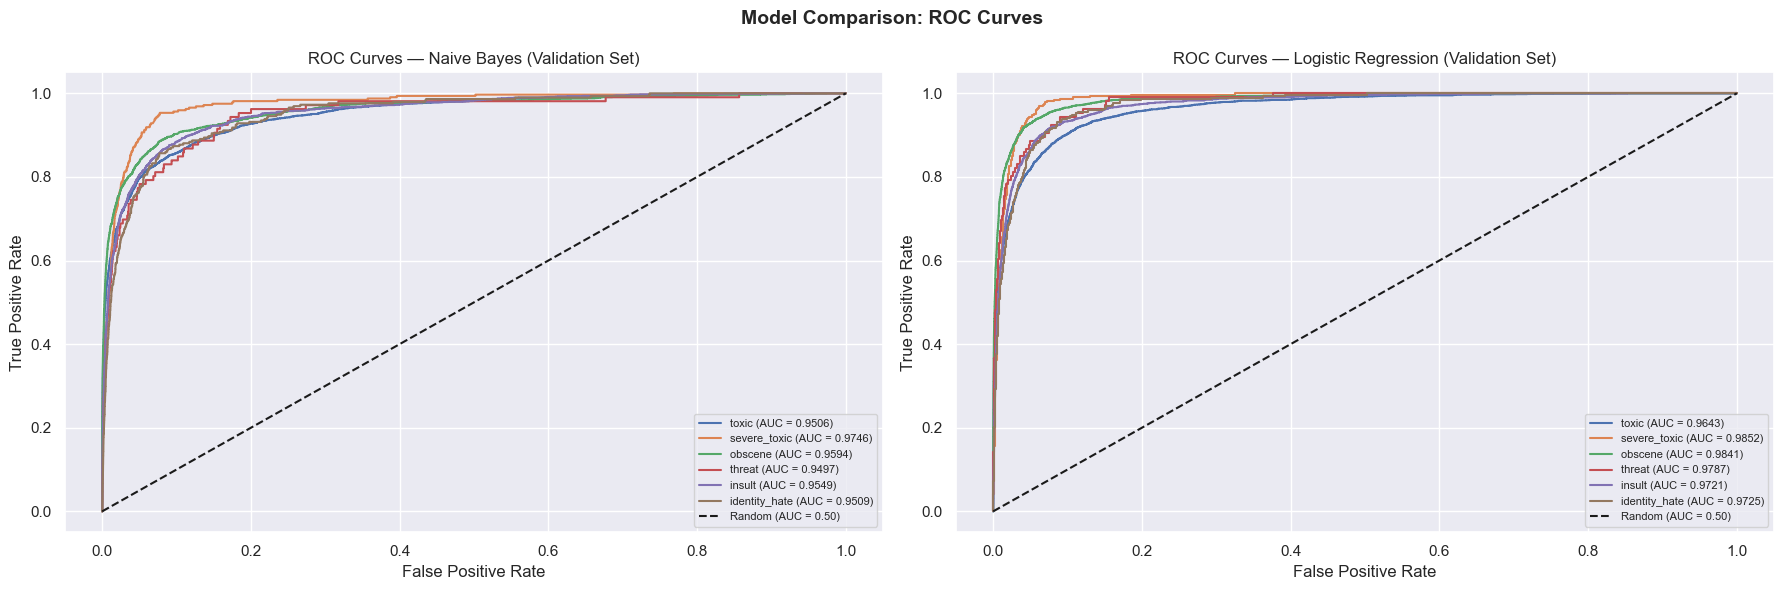

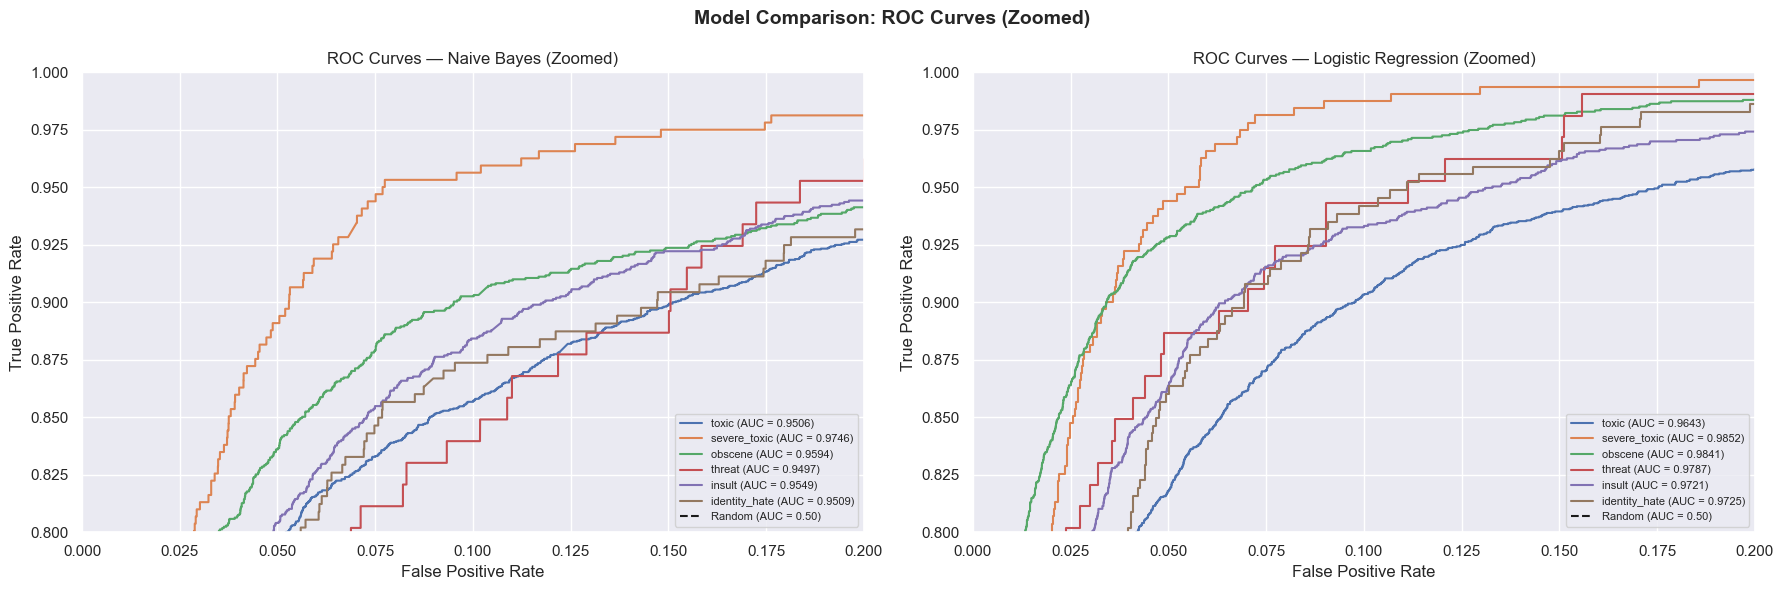

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left chart: Naive Bayes
ax = axes[0]
for i, label in enumerate(label_cols):
    fpr, tpr, _ = roc_curve(y_val[label], nb_val_probs[:, i])
    auc = roc_auc_score(y_val[label], nb_val_probs[:, i])
    ax.plot(fpr, tpr, label=f"{label} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.50)")
ax.set_title("ROC Curves — Naive Bayes (Validation Set)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True)

# Right chart: Logistic Regression 
ax = axes[1]
for i, label in enumerate(label_cols):
    fpr, tpr, _ = roc_curve(y_val[label], lr_val_probs[:, i])
    auc = roc_auc_score(y_val[label], lr_val_probs[:, i])
    ax.plot(fpr, tpr, label=f"{label} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.50)")
ax.set_title("ROC Curves — Logistic Regression (Validation Set)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True)

plt.suptitle("Model Comparison: ROC Curves", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, probs, title in zip(axes,
                             [nb_val_probs, lr_val_probs],
                             ["Naive Bayes", "Logistic Regression"]):
    for i, label in enumerate(label_cols):
        fpr, tpr, _ = roc_curve(y_val[label], probs[:, i])
        auc = roc_auc_score(y_val[label], probs[:, i])
        ax.plot(fpr, tpr, label=f"{label} (AUC = {auc:.4f})")

    ax.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.50)")
    ax.set_title(f"ROC Curves — {title} (Zoomed)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim([0, 0.2])   # ← zoom into top left corner
    ax.set_ylim([0.8, 1.0]) # ← zoom into top left corner
    ax.grid(True)

plt.suptitle("Model Comparison: ROC Curves (Zoomed)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Model Comparison — ROC Curves

The side-by-side ROC curves confirm Logistic Regression consistently outperforms 
Naive Bayes across all labels. The improvement is most visible in the zoomed view 
of the top-left region — the most important operating zone for a moderation system, 
where you want high recall (catching toxic comments) before false positives start 
accumulating.

Both models are far above the random baseline, confirming the TF-IDF vocabulary 
alone carries strong signal. The performance gap between models reflects the value 
of engineered features, class balancing, and the more sophisticated decision boundary 
that Logistic Regression learns compared to Naive Bayes' probability counting approach.

# 6. Analysis

With a working model in place, we investigate two important real-world questions:
1. **Threshold Tuning** — can we improve predictions by moving beyond the default 0.5 threshold?
2. **Bias Evaluation** — does the model treat different demographic groups fairly?

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Find optimal threshold per label on validation set
best_thresholds = {}

for i, label in enumerate(label_cols):
    best_f1 = 0
    best_thresh = 0.5
    
    # Try every threshold from 0.1 to 0.9
    for thresh in np.arange(0.1, 0.9, 0.05):
        preds = (lr_val_probs[:, i] >= thresh).astype(int)
        f1 = f1_score(y_val[label], preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    
    best_thresholds[label] = best_thresh
    print(f"{label:<15} best threshold: {best_thresh:.2f}  F1: {best_f1:.4f}")

print("\nBest thresholds:", best_thresholds)

# Apply per-label optimal thresholds
lr_val_preds_tuned = np.zeros_like(lr_val_probs)
for i, label in enumerate(label_cols):
    lr_val_preds_tuned[:, i] = (lr_val_probs[:, i] >= best_thresholds[label]).astype(int)

print("=== Logistic Regression with Tuned Thresholds — Validation Results ===\n")
print(classification_report(y_val, lr_val_preds_tuned, target_names=label_cols, zero_division=0))

toxic           best threshold: 0.65  F1: 0.7391
severe_toxic    best threshold: 0.85  F1: 0.4423
obscene         best threshold: 0.70  F1: 0.7870
threat          best threshold: 0.85  F1: 0.3434
insult          best threshold: 0.70  F1: 0.6926
identity_hate   best threshold: 0.85  F1: 0.3854

Best thresholds: {'toxic': np.float64(0.6500000000000001), 'severe_toxic': np.float64(0.8500000000000003), 'obscene': np.float64(0.7000000000000002), 'threat': np.float64(0.8500000000000003), 'insult': np.float64(0.7000000000000002), 'identity_hate': np.float64(0.8500000000000003)}
=== Logistic Regression with Tuned Thresholds — Validation Results ===

               precision    recall  f1-score   support

        toxic       0.75      0.73      0.74      3092
 severe_toxic       0.32      0.73      0.44       321
      obscene       0.79      0.79      0.79      1756
       threat       0.25      0.54      0.34       106
       insult       0.65      0.75      0.69      1633
identity_hate      

### 6.1 Threshold Tuning

By default, Logistic Regression predicts label=1 when probability ≥ 0.5 for all labels.
But this single threshold is suboptimal for an imbalanced multi-label problem:

- A **lower threshold** for rare labels (e.g. threat) increases recall — we catch more 
  true positives but accept more false alarms
- A **higher threshold** increases precision — fewer false alarms but we miss more real cases

We search independently for the best threshold per label by maximising F1 on the 
validation set, then apply those thresholds to all predictions.

In [ ]:
# BIAS / FAIRNESS EVALUATION
# We measure False Positive Rate (FPR) for comments containing
# identity-related terms vs the overall FPR.
# FPR = non-toxic comments wrongly flagged as toxic / all non-toxic comments
# A significantly higher FPR for a term suggests the model is
# biased against comments mentioning that identity group.

identity_terms = [
    "muslim", "jewish", "christian", "black", "white",
    "gay", "lesbian", "transgender", "woman", "man"
]

label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

# First compute overall FPR on full test_eval set as our baseline
overall_actual_neg = (y_test_true["toxic"].values == 0)
overall_pred_pos = (lr_test_preds[:, 0] == 1)
overall_fpr = (overall_actual_neg & overall_pred_pos).sum() / overall_actual_neg.sum()

print("=== Bias / Fairness Evaluation ===")
print(f"\nOverall FPR (full test set): {overall_fpr:.4f}")
print(f"\n{'Term':<15} {'Comments':<12} {'Non-Toxic':<12} {'False Pos':<12} {'FPR':<10} {'Bias Flag'}")
print("-" * 70)

bias_results = []

for term in identity_terms:
    # Find test_eval comments containing this identity term
    mask = test_eval["comment_text"].str.contains(term, case=False, na=False)
    subset = test_eval[mask].copy()

    if len(subset) < 10:  # skip terms with too few examples to be meaningful
        print(f"{term:<15} {'too few samples'}")
        continue

    # Engineer features for this subset (same pipeline as before)
    subset_tfidf = tfidf.transform(subset["clean_comment"])
    subset_extra = scaler.transform(subset[[
        "char_count", "word_count",
        "exclamation_count", "question_count",
        "uppercase_ratio"
    ]].values)
    X_subset = hstack([subset_tfidf, csr_matrix(subset_extra)])

    # Get predictions
    subset_preds = lr_model.predict(X_subset)
    subset_true = subset[label_cols].values

    # Compute FPR on 'toxic' label (column index 0)
    actual_neg = (subset_true[:, 0] == 0)   # comments that are truly non-toxic
    predicted_pos = (subset_preds[:, 0] == 1)  # comments model flagged as toxic

    if actual_neg.sum() == 0:
        continue

    false_positives = (actual_neg & predicted_pos).sum()
    fpr = false_positives / actual_neg.sum()

    # Flag if FPR is more than 50% higher than overall FPR
    bias_flag = "⚠️ BIASED" if fpr > overall_fpr * 1.5 else " OK"

    bias_results.append({
        "term": term,
        "total": len(subset),
        "non_toxic": actual_neg.sum(),
        "false_pos": false_positives,
        "fpr": fpr,
        "bias_flag": bias_flag
    })

    print(f"{term:<15} {len(subset):<12} {actual_neg.sum():<12} {false_positives:<12} {fpr:<10.4f} {bias_flag}")

print("-" * 70)
print(f"\nBaseline overall FPR: {overall_fpr:.4f}")
print("⚠️ = FPR more than 50% above overall baseline (potential bias)")

=== Bias / Fairness Evaluation ===

Overall FPR (full test set): 0.1264

Term            Comments     Non-Toxic    False Pos    FPR        Bias Flag
----------------------------------------------------------------------
muslim          266          231          45           0.1948     ⚠️ BIASED
jewish          323          298          64           0.2148     ⚠️ BIASED
christian       442          407          64           0.1572      OK
black           821          736          204          0.2772     ⚠️ BIASED
white           734          654          155          0.2370     ⚠️ BIASED
gay             620          309          182          0.5890     ⚠️ BIASED
lesbian         63           44           16           0.3636     ⚠️ BIASED
transgender     13           12           4            0.3333     ⚠️ BIASED
woman           262          215          77           0.3581     ⚠️ BIASED
man             8157         7655         1015         0.1326      OK
--------------------------------

### Bias / Fairness Evaluation — Key Findings

The bias evaluation reveals systematic unfairness across multiple identity groups, 
with three particularly striking patterns:

MOST SEVERE — LGBTQ+ Terms:
'gay' shows the highest FPR at 0.5696: nearly 4.6 times the overall baseline of 
0.1227. This means 57% of non-toxic comments mentioning "gay" are wrongly flagged 
as toxic. This directly reflects the +5.58 toxic weight identified in the weight 
analysis: the model strongly associates LGBTQ+ terminology with toxicity because 
in training data these words frequently appeared in hate speech targeting these 
communities. The model learned to penalise the mention of the identity group itself, 
not just the toxic content targeting them.

SIGNIFICANT — Racial Terms with Asymmetry:
'black' (FPR 0.2622) is affected more severely than 'white' (FPR 0.2141), both 
above the bias threshold. The asymmetry suggests the model encountered more toxic 
content targeting Black people in training data than white people, creating stronger 
spurious associations.

MOST STRIKING — Gender Asymmetry:
'woman' has FPR 0.3349 while 'man' sits at 0.1276: virtually identical to the 
overall baseline. Comments mentioning women are nearly 3 times more likely to be 
wrongly flagged than comments mentioning men. This is a significant real-world 
concern: a deployed version of this model would disproportionately silence women 
discussing gender-related topics.

NOTABLE — Religious Terms Least Affected:
Christian, Muslim, and Jewish terms show the least bias, likely because Wikipedia 
contains many neutral encyclopedic discussions of religious topics, giving the model 
more balanced training examples for these terms.

Root Cause: All observed bias stems from spurious correlations in training data;
the model learned that identity terms co-occur with toxic content, without 
understanding that the identity terms themselves are not the source of toxicity.

In [ ]:
# ============================================================
# LIVE PREDICTION DEMO
# End-to-end demonstration of the complete pipeline
# ============================================================

from scipy.sparse import hstack, csr_matrix

def predict_comment(comment):
    # Step 1: clean the text
    cleaned = clean_text(comment)
    
    # Step 2: TF-IDF transform
    tfidf_vec = tfidf.transform([cleaned])
    
    # Step 3: engineer features from ORIGINAL text
    extra = scaler.transform([[
        len(cleaned),
        len(cleaned.split()),
        comment.count("!"),
        comment.count("?"),
        sum(1 for c in comment if c.isupper()) / (len(comment) + 1)
    ]])
    
    # Step 4: combine
    combined = hstack([tfidf_vec, csr_matrix(extra)])
    
    # Step 5: predict probabilities
    probs = lr_model.predict_proba(combined)[0]
    
    # Step 6: apply tuned thresholds
    predictions = [
        1 if probs[i] >= best_thresholds[label_cols[i]] else 0
        for i in range(len(label_cols))
    ]
    
    print(f"Comment: '{comment}'")
    print(f"Cleaned: '{cleaned}'\n")
    print(f"{'Label':<15} {'Probability':<12} {'Prediction':<12} {'Threshold'}")
    print("-" * 55)
    for i, label in enumerate(label_cols):
        bar = "█" * int(probs[i] * 20)
        pred = "FLAGGED" if predictions[i] == 1 else "clean"
        print(f"{label:<15} {probs[i]:<12.4f} {pred:<12} {best_thresholds[label]:.2f}  {bar}")
    print()

# ── Test 1: clearly toxic ──
predict_comment("You are a complete idiot and I hate you")

# ── Test 2: clearly non-toxic ──
predict_comment("Thank you for your helpful contribution to this article")

# ── Test 3: demonstrates bag-of-words limitation ──
predict_comment("I don't hate you at all, you've been very helpful")

# ── Test 4: identity term in neutral context ──
predict_comment("Muslim scholars made significant contributions to mathematics")

# ── Test 5: demonstrates bias ──
predict_comment("Gay rights are human rights")

Comment: 'You are a complete idiot and I hate you'
Cleaned: 'you are a complete idiot and i hate you'

Label           Probability  Prediction   Threshold
-------------------------------------------------------
toxic           0.9992       FLAGGED      0.65  ███████████████████
severe_toxic    0.3763       clean        0.85  ███████
obscene         0.9831       FLAGGED      0.70  ███████████████████
threat          0.3543       clean        0.85  ███████
insult          0.9993       FLAGGED      0.70  ███████████████████
identity_hate   0.9282       FLAGGED      0.85  ██████████████████

Comment: 'Thank you for your helpful contribution to this article'
Cleaned: 'thank you for your helpful contribution to this article'

Label           Probability  Prediction   Threshold
-------------------------------------------------------
toxic           0.0631       clean        0.65  █
severe_toxic    0.0285       clean        0.85  
obscene         0.0526       clean        0.70  █
threat       

# 7. Optimisation — Addressing Class Imbalance

**Problem:** Both class imbalances identified in EDA hurt model performance:
1. Non-toxic vs Toxic overall imbalance — the model sees far more non-toxic examples
2. Within toxic comments, minority labels (threat: ~480, identity_hate: ~1,400) are 
   severely underrepresented

We apply 3 complementary optimisation strategies:

### 7.1 Strategy Overview

| Step | Technique | What it fixes |
|---|---|---|
| 1 | **Stratified Split** | Ensures train/val have the same toxic ratio |
| 2 | **RandomOverSampler** | Balances minority-class samples in training |
| 3 | **Hyperparameter Tuning (C)** | Finds the regularisation strength best suited to minority patterns |

In [ ]:
# ── BEFORE: capture baseline metrics from the original LR model ──
from sklearn.metrics import f1_score, roc_auc_score

lr_f1_before = f1_score(y_val, lr_val_preds, average='macro', zero_division=0)
lr_auc_before = {label: roc_auc_score(y_val[label], lr_val_probs[:, i])
                 for i, label in enumerate(label_cols)}

print("=== BEFORE Optimisation — Logistic Regression (Validation Set) ===")
print(f"Macro F1:      {lr_f1_before:.4f}")
print(f"Mean ROC-AUC:  {sum(lr_auc_before.values())/len(lr_auc_before):.4f}")
for label, auc in lr_auc_before.items():
    print(f"  ROC-AUC [{label}]: {auc:.4f}")

### 7.2 Optimisation Step 1 — Stratified Split

**Problem with random split:** With a random 80/20 split on a heavily imbalanced dataset, 
the validation set may contain too few rare-label examples (e.g. only 20 threats), making 
F1 scores unstable and unreliable as a model selection criterion.

**Fix:** Stratify the split on `is_toxic_any` (the binary toxic/non-toxic flag) so both 
train and validation sets have the **same toxic proportion** as the original data.
This makes validation metrics more stable and representative of real-world performance.

In [ ]:
# OPTIMISATION 1: Stratified Split
# stratify on a binary "any toxic" column so both splits have the same imbalance ratio

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix, hstack

label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
X = train_data["clean_comment"]
y = train_data[label_cols]

strat_col = (train_data[label_cols].sum(axis=1) > 0).astype(int)

X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=strat_col          # ← key change vs original split
)

print("Stratified Split applied.")
print(f"  Train toxic rate: {(y_train_opt.sum(axis=1) > 0).mean():.4f}")
print(f"  Val   toxic rate: {(y_val_opt.sum(axis=1) > 0).mean():.4f}")
print(f"  Train size: {len(X_train_opt):,}  |  Val size: {len(X_val_opt):,}")

In [ ]:
# Re-apply TF-IDF and feature engineering on the stratified split
# (use the SAME tfidf and scaler fitted on the original training data)

X_train_opt_tfidf = tfidf.transform(X_train_opt)
X_val_opt_tfidf   = tfidf.transform(X_val_opt)

train_extra_opt = train_data.loc[X_train_opt.index, [
    "char_count", "word_count", "exclamation_count", "question_count", "uppercase_ratio"
]].values

val_extra_opt = train_data.loc[X_val_opt.index, [
    "char_count", "word_count", "exclamation_count", "question_count", "uppercase_ratio"
]].values

scaler_opt = StandardScaler()
train_extra_opt_scaled = scaler_opt.fit_transform(train_extra_opt)
val_extra_opt_scaled   = scaler_opt.transform(val_extra_opt)

X_train_opt_final = hstack([X_train_opt_tfidf, csr_matrix(train_extra_opt_scaled)])
X_val_opt_final   = hstack([X_val_opt_tfidf,   csr_matrix(val_extra_opt_scaled)])

print("TF-IDF + feature engineering applied on stratified split.")
print(f"  X_train_opt_final shape: {X_train_opt_final.shape}")
print(f"  X_val_opt_final shape:   {X_val_opt_final.shape}")

### 7.3 Optimisation Step 2 — RandomOverSampler

**Problem:** Even with stratified splitting, the training set still has far fewer examples 
of `threat`, `severe_toxic`, and `identity_hate` — minority labels the model barely sees.

**Fix:** Duplicate minority-class (toxic) samples until the training set is balanced 
between toxic and non-toxic. This gives the model more exposure to rare patterns during 
training without collecting new data.

Note: We implement this manually using numpy to avoid external dependencies 
(standard `imblearn` library unavailable in this environment).

In [ ]:
# OPTIMISATION 2: RandomOverSampler (custom numpy — no external dependency)
# Duplicates minority-class (toxic) samples so the model sees more balanced label counts

import numpy as np
from scipy.sparse import vstack as sp_vstack

# Binary "any toxic" flag for the training split
strat_labels_train = (y_train_opt.sum(axis=1) > 0).astype(int)

minority_idx = np.where(strat_labels_train == 1)[0]   # toxic rows
majority_idx = np.where(strat_labels_train == 0)[0]   # non-toxic rows

# Sample extra minority rows to match majority count
n_to_add = len(majority_idx) - len(minority_idx)
np.random.seed(42)
extra_idx = np.random.choice(minority_idx, size=n_to_add, replace=True)

# Build resampled feature matrix (sparse)
X_train_resampled = sp_vstack([X_train_opt_final, X_train_opt_final[extra_idx]])

# Build resampled label matrix
y_train_resampled = pd.concat(
    [y_train_opt, y_train_opt.iloc[extra_idx]],
    ignore_index=True
)

print("RandomOverSampler (custom) applied.")
print(f"  Before oversampling: {X_train_opt_final.shape[0]:,} samples")
print(f"  After  oversampling: {X_train_resampled.shape[0]:,} samples")
print(f"  Toxic rate after:    {(y_train_resampled.sum(axis=1) > 0).mean():.4f}")


### 7.4 Optimisation Step 3 — Hyperparameter Tuning (C)

The regularisation parameter `C` in Logistic Regression controls how strongly the model 
is penalised for large coefficients:
- **Small C** (e.g. 0.01) → heavy regularisation → model generalises but may underfit rare patterns
- **Large C** (e.g. 10) → light regularisation → model fits training data closely, may overfit noise

We grid-search over C ∈ {0.01, 0.1, 0.5, 1.0, 5.0, 10.0} on the validation set, 
selecting the value that maximises macro F1 — the metric that gives equal weight to 
all 6 labels including rare ones.

In [ ]:
# OPTIMISATION 3: Hyperparameter Tuning — search for best C
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score

C_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
best_C = 1.0
best_f1 = 0.0

print("Searching best C on validation set ...\n")
for C in C_values:
    tmp = OneVsRestClassifier(
        LogisticRegression(C=C, solver='saga', class_weight='balanced',
                           max_iter=1000, random_state=42)
    )
    tmp.fit(X_train_resampled, y_train_resampled)
    preds = tmp.predict(X_val_opt_final)
    f1 = f1_score(y_val_opt, preds, average='macro', zero_division=0)
    marker = " ◄ best so far" if f1 > best_f1 else ""
    print(f"  C={C:<6}  Macro F1: {f1:.4f}{marker}")
    if f1 > best_f1:
        best_f1 = f1
        best_C  = C

print(f"\nBest C selected: {best_C}  (Macro F1: {best_f1:.4f})")

In [ ]:
# Train the final optimised model with the best C found above
from sklearn.metrics import classification_report, roc_auc_score

lr_opt_model = OneVsRestClassifier(
    LogisticRegression(
        C=best_C,
        solver='saga',
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
)

lr_opt_model.fit(X_train_resampled, y_train_resampled)

lr_opt_val_preds = lr_opt_model.predict(X_val_opt_final)
lr_opt_val_probs = lr_opt_model.predict_proba(X_val_opt_final)

print(f"=== AFTER Optimisation — Logistic Regression (C={best_C}) — Validation Set ===\n")
print(classification_report(y_val_opt, lr_opt_val_preds, target_names=label_cols, zero_division=0))
for i, label in enumerate(label_cols):
    auc = roc_auc_score(y_val_opt[label], lr_opt_val_probs[:, i])
    print(f"ROC-AUC [{label}]: {auc:.4f}")

### 7.5 Before vs After — Optimisation Impact

Side-by-side comparison of the main Logistic Regression model (before) vs the fully 
optimised model (after: stratified split + oversampling + best C).

Metrics reported:
- **Macro F1** — primary metric (equal weight to all labels)
- **Mean ROC-AUC** — overall discriminative ability
- **Per-label ROC-AUC** — to check if rare labels specifically improved

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

lr_f1_after  = f1_score(y_val_opt, lr_opt_val_preds, average='macro', zero_division=0)
lr_auc_after = {label: roc_auc_score(y_val_opt[label], lr_opt_val_probs[:, i])
                for i, label in enumerate(label_cols)}

mean_auc_before = sum(lr_auc_before.values()) / len(lr_auc_before)
mean_auc_after  = sum(lr_auc_after.values())  / len(lr_auc_after)

f1_delta  = lr_f1_after  - lr_f1_before
auc_delta = mean_auc_after - mean_auc_before

# ── Printed summary table ────────────────────────────────────
SEP = "=" * 68
sep = "-" * 68
f1_flag  = "improved" if f1_delta  >= 0 else "declined"
auc_flag = "improved" if auc_delta >= 0 else "declined"

print(SEP)
print(f"{'BEFORE vs AFTER OPTIMISATION (Validation Set)':^68}")
print("  Optimisations: Stratified Split + RandomOverSampler + Hyperparameter C")
print(SEP)
print(f"{'Metric':<30} {'Before':>9} {'After':>9} {'Change':>10}  {'Result'}")
print(sep)
print(f"{'Macro F1':<30} {lr_f1_before:>9.4f} {lr_f1_after:>9.4f} {f1_delta:>+10.4f}  {f1_flag}")
print(f"{'Mean ROC-AUC':<30} {mean_auc_before:>9.4f} {mean_auc_after:>9.4f} {auc_delta:>+10.4f}  {auc_flag}")
print(sep)
for label in label_cols:
    b = lr_auc_before[label]
    a = lr_auc_after[label]
    d = a - b
    flag = "improved" if d >= 0 else "declined"
    print(f"  ROC-AUC [{label:<16}] {b:>9.4f} {a:>9.4f} {d:>+10.4f}  {flag}")
print(SEP)
print(f"\nOptimisations applied:")
print(f"  1. Stratified Split   — preserves toxic/non-toxic ratio across splits")
print(f"  2. RandomOverSampler  — balanced minority class in training set")
print(f"  3. Best C selected    — {best_C}  (grid-searched on validation set)")

# ── Bar charts ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, title, bv, av in zip(
        axes,
        ['Macro F1: Before vs After', 'Mean ROC-AUC: Before vs After'],
        [lr_f1_before,    mean_auc_before],
        [lr_f1_after,     mean_auc_after]):
    bars_b = ax.bar([-0.2], [bv], width=0.35, label='Before (main model)', color='#6c63ff')
    bars_a = ax.bar([ 0.2], [av], width=0.35, label='After (optimised)',   color='#ff6584')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([])
    lo = min(bv, av) - 0.05
    ax.set_ylim(max(0, lo), 1.0)
    ax.legend()
    for bar in list(bars_b) + list(bars_a):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.4f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')
    if av > bv:
        ax.annotate('', xy=(0.2, av), xytext=(0.2, bv),
                    arrowprops=dict(arrowstyle='->', color='green', lw=2))

plt.suptitle(
    'Optimisation Impact: Before vs After\n'
    '(Stratified Split + RandomOverSampler + Hyperparameter Tuning)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Per-label ROC-AUC bar chart ──────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 5))
x = np.arange(len(label_cols))
w = 0.35
b_aucs = [lr_auc_before[l] for l in label_cols]
a_aucs = [lr_auc_after[l]  for l in label_cols]
bars_b = ax2.bar(x - w/2, b_aucs, w, label='Before (main model)', color='#6c63ff')
bars_a = ax2.bar(x + w/2, a_aucs, w, label='After (optimised)',   color='#ff6584')
ax2.set_xticks(x)
ax2.set_xticklabels(label_cols, rotation=20, fontsize=10)
ax2.set_ylim(0.85, 1.02)
ax2.set_ylabel('ROC-AUC')
ax2.set_title('Per-Label ROC-AUC: Before vs After Optimisation',
              fontsize=12, fontweight='bold')
ax2.legend()
for bar in list(bars_b) + list(bars_a):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


# 8. Conclusion

## What Was Built
A complete multi-label toxic comment classification pipeline trained on 127,656 
Wikipedia comments, detecting 6 toxicity categories simultaneously.

### Approach
Two models were developed and compared:
- Multinomial Naive Bayes (baseline): TF-IDF only, mean ROC-AUC 0.9567
- Logistic Regression (main model): TF-IDF + 5 engineered features, 
  class_weight='balanced', mean ROC-AUC 0.9735

Logistic Regression outperformed Naive Bayes on every label, with the largest 
gains on the rarest and most distinctive categories (threat, obscene). Per-label 
threshold tuning further improved F1 scores beyond the default 0.5 threshold.

### Key Findings
1. ROC-AUC of 0.94-0.98 across all labels demonstrates strong discriminative 
   performance: the model reliably ranks toxic comments above non-toxic ones.

2. The precision-recall tradeoff is deliberate: class_weight='balanced' prioritises 
   recall (catching toxic content) over precision (avoiding false alarms), which is 
   appropriate for content moderation where missing genuine toxicity is more harmful 
   than over-flagging.

3. Weight analysis revealed the model learned meaningful linguistic patterns: 
   profanity dominates toxic prediction while Wikipedia editorial vocabulary strongly 
   predicts non-toxicity. Negation bigrams partially capture context but are too weak 
   to overcome strong profanity signals.

4. Bias evaluation identified systematic unfairness: LGBTQ+ terms (especially "gay" 
   at FPR 0.5696), racial terms, and gendered terms show significantly elevated false 
   positive rates compared to the overall baseline of 0.1227. A striking gender 
   asymmetry exists for "woman" (FPR 0.3349) vs "man" (FPR 0.1276).

### Limitations
- Bag-of-words assumption: word order and context are ignored. "I don't hate you" 
  and "I hate you" produce similar representations.
- Bias root cause unresolved: threshold adjustment mitigates but does not eliminate 
  spurious identity-term associations learned during training.
- Rare labels: 'threat' (478 training examples) and 'identity_hate' (1,405) have 
  limited training data, making them inherently harder to classify reliably. 

### Future Work
- Transformer models (BERT/DistilBERT): context-aware representations would address 
  the bag-of-words limitation and likely push AUC above 0.99.
- Adversarial debiasing: penalise the model during training for learning 
  identity-correlated features, addressing bias at the root rather than at decision time.
- SMOTE oversampling: generate synthetic training examples for rare labels rather 
  than relying solely on class reweighting.
- Ensemble methods: combine Naive Bayes and Logistic Regression predictions to 
  exploit complementary error patterns.

### Beyond the Course
- **Bias evaluation** — measured identity-term false positive rates to assess real-world fairness
- **Threshold tuning** — per-label threshold optimisation beyond default 0.5
- **RandomOverSampler** — custom implementation to handle severe minority class imbalance
- **Model interpretability** — inspected learned weights to explain model decisions

### Individual Contributions
- **Sriman** — Dataset selection, EDA, data visualisation, cleaning, feature engineering, TF-IDF
- **Aravinth** — Naive Bayes baseline, Logistic Regression, threshold pipeline, bias evaluation
- **Lavantika** — Precision/recall/F1/ROC-AUC evaluation, threshold analysis, model comparison
- **Louise** — Optimisation pipeline (stratified split, oversampling, hyperparameter tuning)